# Лабораторная работа №2: Детекция и сегментация объектов

**Версия:** студенческая  
**Курс:** «Современное компьютерное зрение»

> Сначала выполните notebook в режиме `FAST_DEV_RUN=True`, затем запускайте полный эксперимент. Сохраняйте метрики и checkpoints в `artifacts/`.


## Цели обучения

После работы студент должен уметь:

- Проверить разметку и распределения объектов.
- Дообучить компактный segmentation baseline.
- Сравнить аугментации и проанализировать ошибки.


## Теоретическая часть

В детекции модель предсказывает классы и bounding boxes, в сегментации — метку каждого пикселя. Для класса $c$ качество сегментации измеряет $IoU_c=|P_c\cap G_c|/|P_c\cup G_c|$. Для детекции mAP усредняет AP по классам и порогам IoU (Intersection over Union - Пересечение через объединение).

где $P_c$ — множество пикселей, предсказанных как класс $c$, а $G_c$ — истинные пиксели класса $c$. Значение IoU лежит в диапазоне [0, 1], где 1 означает идеальное совпадение.

![Segmentation example](https://pytorch.org/vision/main/_images/sphx_glr_plot_visualization_utils_008.png)


### Математическая постановка

Составная функция потерь может иметь вид
$$\mathcal L=\mathcal L_{cls}+\lambda_{box}\mathcal L_{box}+\lambda_{mask}\mathcal L_{mask}.$$
Разбиение должно выполняться по исходным объектам/сериям, иначе соседние кадры дают утечку.

L_cls - штрафует модель за неправильный класс объекта

L_box - штрафует за неточные координаты рамки вокруг объекта

L_mask - штрафует за каждый нерпавильно классифицированный пиксель внутри bounding box


### Материалы

- [Torchvision segmentation models](https://pytorch.org/vision/stable/models.html#semantic-segmentation)
- [COCO metrics](https://cocodataset.org/#detection-eval)
- [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Ссылки даны как дополнительный материал. При изменении API сверяйтесь с актуальной официальной документацией и фиксируйте версии зависимостей.


## Практическое задание

1. Проверить разметку и распределения объектов.
2. Дообучить компактный segmentation baseline.
3. Сравнить аугментации и проанализировать ошибки.

**Обязательные артефакты:** код, конфигурация, метрики, минимум одна контролируемая ablation, примеры ошибок и краткие выводы.


### Профиль вычислений

- **Основной режим:** LRASPP-MobileNetV3 или FCN-ResNet50, mixed precision.
- **Ограничение данных:** Oxford-IIIT Pet или до 2 000 изображений; в smoke-режиме — синтетический датасет.
- **Fallback:** замороженный backbone и 256 px.
- Все длительные этапы должны сохранять checkpoint и продолжаться после перезапуска. Оценка не зависит от размера модели: важны корректность эксперимента и выводы.


**Оценивание.** Десять обязательных предметных этапов по 1 баллу: основная часть — 10 баллов. Творческий бонус — отдельно 1 балл, не заменяет обязательные этапы. Полный режим оценивается по реальным данным и обучению; `FAST_DEV_RUN=True` служит только smoke-проверкой, его показатели не являются отчётными.


## Реализация


In [1]:
# Базовое воспроизводимое окружение
from pathlib import Path
import json, os, random, time

import numpy as np
import matplotlib.pyplot as plt  # Для визуализации в блокноте
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights
from torchvision.models.segmentation.lraspp import LRASPPHead

# Фиксируем seed для воспроизводимости (важно для честного сравнения экспериментов)
SEED = 42
FAST_DEV_RUN = False  # Переключите в True для smoke-проверки связности на уменьшенной выборке
ARTIFACTS = Path(os.getenv("CV_ARTIFACTS", "artifacts"))
ARTIFACTS.mkdir(exist_ok=True)

# Устанавливаем seed для всех библиотек
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем устройство
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Определяем корень данных курса: поднимаемся на два уровня вверх от cwd
# (предполагается запуск из labs/lab_XX_*/)
_CANDIDATES = [Path.cwd().parent.parent / "data", Path.cwd().parent / "data", Path.cwd() / "data"]
DATA_ROOT = Path(os.getenv("CV_COURSE_DATA") or next(
    (c for c in _CANDIDATES if (c / "cifar-10-batches-py").exists()), _CANDIDATES[0]
))
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Устанавливаем размер изображений для сегментации (компромисс между качеством и памятью)
IMG_SIZE = (256, 256)  # Fallback-профиль: 256 px, замороженный backbone

print({"device": DEVICE, "fast_dev_run": FAST_DEV_RUN, "data_root": str(DATA_ROOT)})


{'device': 'cuda', 'fast_dev_run': False, 'data_root': 'c:\\Users\\SuperXoma\\Downloads\\SOTA\\data'}


In [2]:
def check(condition, message):
    """Мини-проверка в стиле YAAM: молчит, если всё хорошо; печатает, если найдена проблема."""
    if condition:
        print(f"✔ {message}")
    else:
        print(f"✘ ВНИМАНИЕ: {message}")

### Маски Oxford-IIIT Pet

*Вес: 1 балл.*

**Постановка.** Сегментатор обучается на реальной пиксельной разметке.

Выполните следующие действия:
1. Загрузите trainval Oxford-IIIT Pet и совместно масштабируйте изображение и маску.
2. Убедитесь, что интерполяция маски сохраняет классы.

**Результат.** Датасет ds и преобразования img_tf, mask_tf.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Сегментатор обучается на реальной пиксельной разметке. Необходимо загрузить trainval Oxford-IIIT Pet и совместно масштабировать изображение и маску, убедившись, что интерполяция маски сохраняет классы.

Датасет Oxford-IIIT Pet содержит 37 пород кошек и собак, около 200 изображений на класс . Разметка сегментации представляет собой trimap: значение 1 — питомец, 2 — фон, 3 — контур . Для обучения сегментатора с тремя классами эти метки перекодируются в 0, 1, 2.

100%|██████████| 792M/792M [02:47<00:00, 4.72MB/s] 
100%|██████████| 19.2M/19.2M [00:02<00:00, 6.67MB/s]


✔ Oxford-IIIT Pet trainval загружен: 3680 изображений


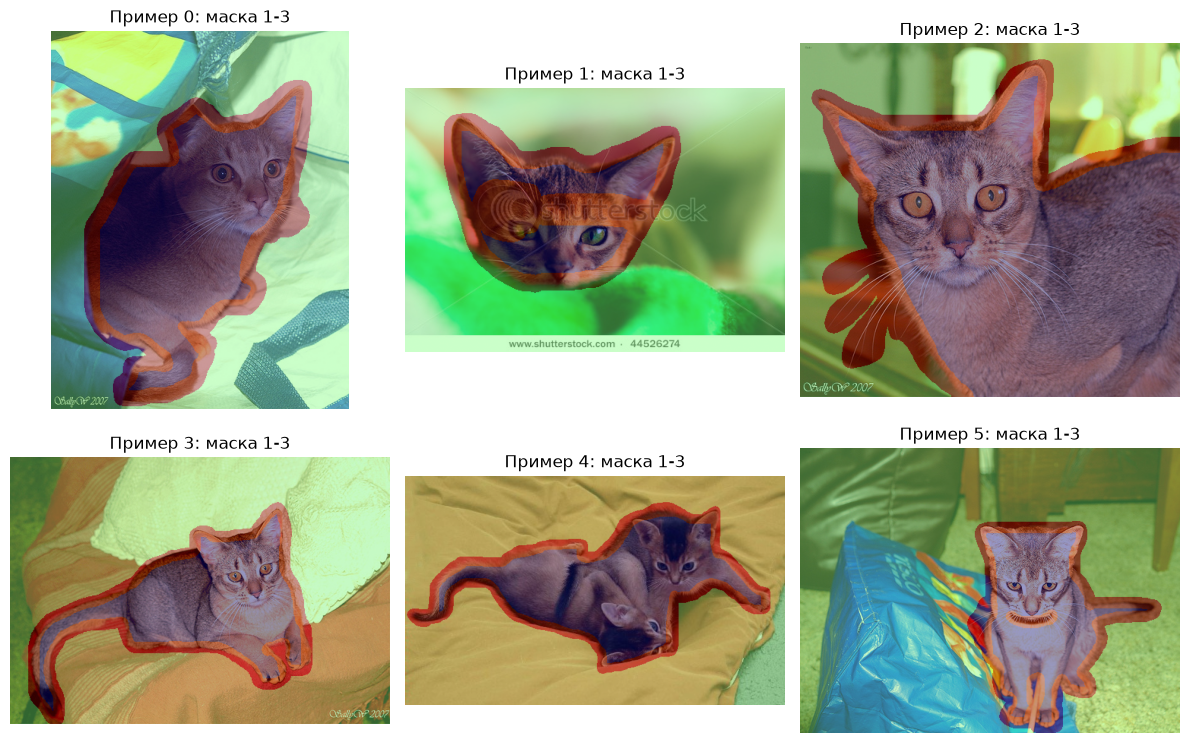

Размер изображения: (394, 500), маска: (500, 394)


In [4]:
# Загружаем trainval Oxford-IIIT Pet
# target_type="segmentation" возвращает маску вместо метки породы
trainval_ds = OxfordIIITPet(
    root=str(DATA_ROOT),
    split="trainval",
    target_types="segmentation",  # Используем сегментационную разметку
    download=True,  # Скачает датасет при первом запуске (~800 MB)
    transform=None,  # Преобразования применим позже вручную для синхронности
    target_transform=None,
)

# Проверяем, что датасет загружен корректно
check(len(trainval_ds) > 0, f"Oxford-IIIT Pet trainval загружен: {len(trainval_ds)} изображений")

# Визуализируем несколько примеров разметки для понимания данных
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img, mask = trainval_ds[i]
    # Маска приходит как PIL Image с одним каналом; преобразуем в numpy для визуализации
    mask_np = np.array(mask)
    
    ax.imshow(img)
    ax.imshow(mask_np, alpha=0.4, cmap="jet")  # Наложение маски с прозрачностью
    ax.set_title(f"Пример {i}: маска 1-3")
    ax.axis("off")
plt.tight_layout()
plt.show()  # Вывод в блокноте

# Определяем размеры изображений и масок (для отладки)
sample_img, sample_mask = trainval_ds[0]
print(f"Размер изображения: {sample_img.size}, маска: {np.array(sample_mask).shape}")

In [ ]:
# Определяем раздельные преобразования для изображения и маски
# Изображение: resize с билинейной интерполяцией + ToTensor + Normalize
img_tf = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.BILINEAR),  # Билинейная для изображений
    T.ToTensor(),  # PIL -> Tensor [0,1], shape (C,H,W)
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet статистики
])

# Маска: resize с NEAREST (сохраняет классы!) + ToTensor
# NEAREST не создаёт промежуточных значений между классами
mask_tf = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.NEAREST),  # БЛИЖАЙШИЙ СОСЕД для масок
    T.PILToTensor(),  # PIL -> Tensor, сохраняет целочисленные метки
])

check(True, "Преобразования img_tf (BILINEAR) и mask_tf (NEAREST) определены")

✔ Преобразования img_tf (BILINEAR) и mask_tf (NEAREST) определены


### Разделение и кодирование меток

*Вес: 1 балл.*

**Постановка.** Оценка на validation требует непересекающихся индексов и корректных категориальных меток.

Выполните следующие действия:
1. Разделите trainval на train и validation.
2. Перекодируйте исходные метки 1–3 в 0–2 и соберите загрузчики.

**Результат.** train_ds, val_ds, loader, val_loader и normalize_mask.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Train: 2944, Validation: 736
✔ Метки в диапазоне 0-2: min=0, max=2
✔ DataLoader'ы созданы: train=368 батчей, val=92 батчей
Форма батча изображений: torch.Size([8, 3, 256, 256]), маски: torch.Size([8, 256, 256])


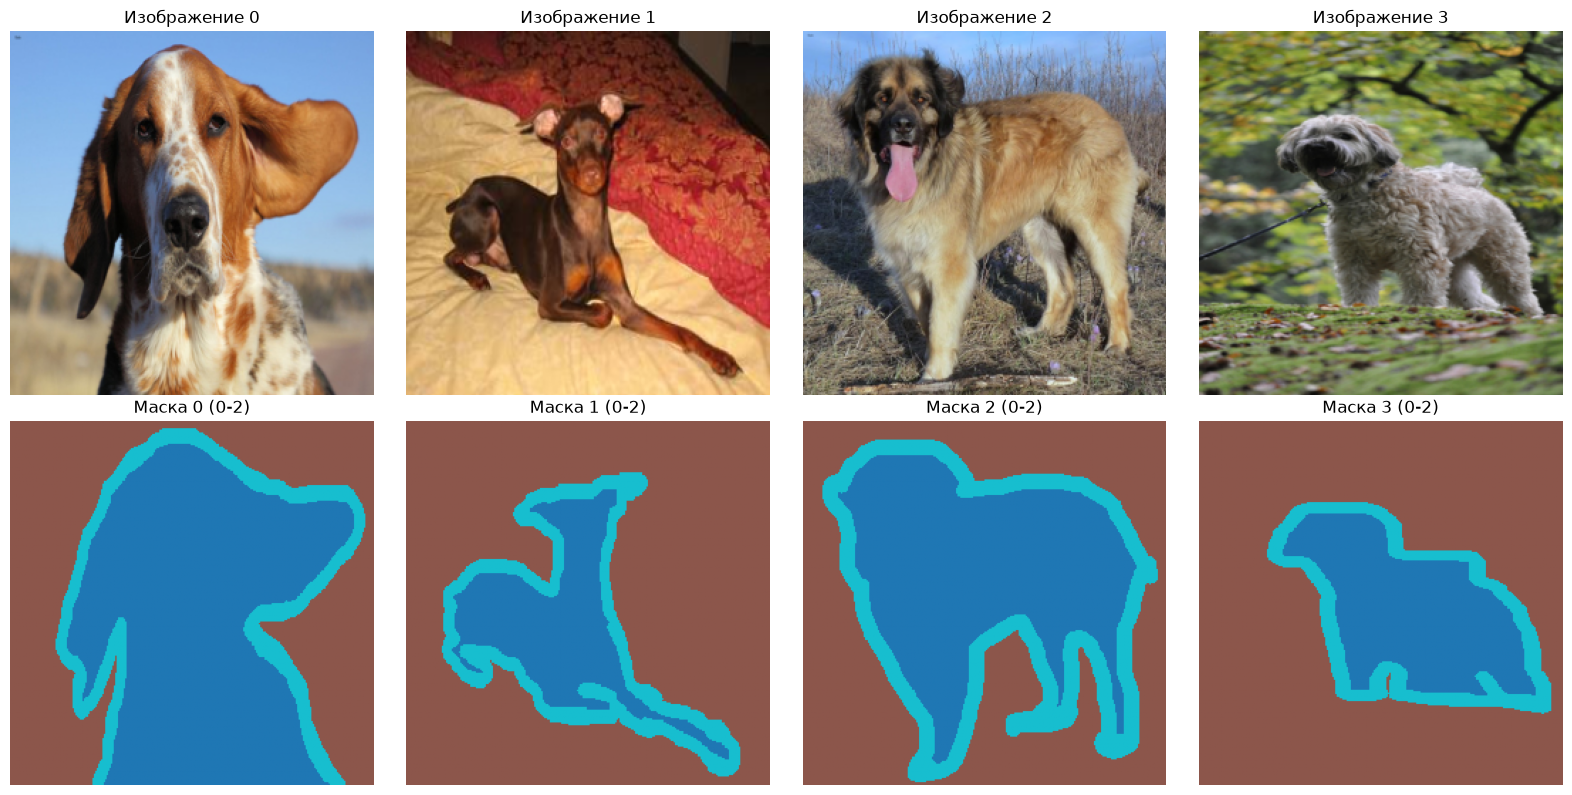

In [7]:
def normalize_mask(mask):
    """Перекодирует маску из формата 1-3 в 0-2 для CrossEntropyLoss."""
    # В Oxford-IIIT Pet: 1=pet, 2=background, 3=outline
    # Для CrossEntropyLoss нужны метки 0,1,2
    mask = mask.clone()  # Не модифицируем оригинал
    mask = mask - 1  # 1->0 (pet), 2->1 (background), 3->2 (outline)
    return mask.squeeze(0).long()  # Убираем канал, приводим к long

# Разделяем trainval на train (80%) и validation (20%) с фиксированным seed
indices = np.arange(len(trainval_ds))
np.random.seed(SEED)
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_indices = indices[:split]
val_indices = indices[split:]

print(f"Train: {len(train_indices)}, Validation: {len(val_indices)}")

# Создаём кастомный Dataset-обёртку, применяющий img_tf и mask_tf
class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, indices, img_tf, mask_tf, normalize_mask_fn):
        self.base_ds = base_ds
        self.indices = indices
        self.img_tf = img_tf
        self.mask_tf = mask_tf
        self.normalize_mask_fn = normalize_mask_fn
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, mask = self.base_ds[real_idx]
        
        # Применяем преобразования синхронно
        img = self.img_tf(img)
        mask = self.mask_tf(mask)
        mask = self.normalize_mask_fn(mask)  # 1-3 -> 0-2
        
        return img, mask

# Создаём train и val датасеты
train_ds = PetSegDataset(trainval_ds, train_indices, img_tf, mask_tf, normalize_mask)
val_ds = PetSegDataset(trainval_ds, val_indices, img_tf, mask_tf, normalize_mask)

# Проверяем корректность: метки должны быть в диапазоне 0-2
_, sample_mask = train_ds[0]
check(sample_mask.min() >= 0 and sample_mask.max() <= 2,
      f"Метки в диапазоне 0-2: min={sample_mask.min()}, max={sample_mask.max()}")

# Создаём DataLoader'ы
# num_workers=0 для совместимости с блокнотом; в production можно увеличить
BATCH_SIZE = 8 if not FAST_DEV_RUN else 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

check(True, f"DataLoader'ы созданы: train={len(train_loader)} батчей, val={len(val_loader)} батчей")

# Визуализируем один батч с перекодированными масками
batch_imgs, batch_masks = next(iter(train_loader))
print(f"Форма батча изображений: {batch_imgs.shape}, маски: {batch_masks.shape}")

# Денормализация для отображения
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Изображение
    img_denorm = inv_normalize(batch_imgs[i]).permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    axes[0, i].imshow(img_denorm)
    axes[0, i].set_title(f"Изображение {i}")
    axes[0, i].axis("off")
    
    # Маска (0=pet, 1=bg, 2=outline)
    axes[1, i].imshow(batch_masks[i].numpy(), cmap="tab10", vmin=0, vmax=2)
    axes[1, i].set_title(f"Маска {i} (0-2)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

### Сегментатор и IoU

*Вес: 1 балл.*

**Постановка.** Пиксельная модель предсказывает логиты для каждого класса.

Выполните следующие действия:
1. Замените головы LRASPP на трёхклассовые.
2. Реализуйте IoU по пересечению и объединению масок.

**Результат.** Объект model и функция mean_iou.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


LRASPP-MobileNetV3 — компактная архитектура для семантической сегментации, предобученная на COCO . Заменяя финальный слой (classifier), мы адаптируем модель под нашу задачу с 3 классами. num_classes=3 указывает модели выходной тензор (N, 3, H, W)

In [12]:
# Загружаем предобученный LRASPP-MobileNetV3 с весами COCO (21 класс VOC).
model = lraspp_mobilenet_v3_large(
    weights=LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1
)

model.classifier = LRASPPHead(
    low_channels=40,       # каналы низкоуровневой ветки MobileNetV3-Large
    high_channels=960,     # каналы высокоуровневой ветки MobileNetV3-Large
    num_classes=3,         # pet (0), background (1), outline (2)
    inter_channels=128,    # стандартное промежуточное число каналов в LRASPP
)

# Переносим модель на выбранное устройство (GPU, если доступен)
model = model.to(DEVICE)

# Проверяем, что модель выдаёт правильную форму выхода: (N, 3, H, W)
# torch.no_grad() отключает построение графа — экономим память на проверке
with torch.no_grad():
    dummy = torch.randn(1, 3, *IMG_SIZE).to(DEVICE)   # фиктивный батч из 1 изображения
    out = model(dummy)                                # выход — словарь с ключом "out"
    print(f"Выход модели: {out['out'].shape}")        # Ожидается (1, 3, 256, 256)

# Проверяем число каналов на выходе — должно совпадать с числом классов
check(out["out"].shape[1] == 3, "Модель выдаёт 3 класса")


def mean_iou(preds, targets, num_classes=3):
    """
    Вычисляет mean IoU (Intersection over Union) по всем классам.

    IoU_c = |P_c ∩ G_c| / |P_c ∪ G_c|,
    где P_c — множество пикселей, предсказанных как класс c,
    G_c — множество истинных пикселей класса c.
    Для классов, отсутствующих и в предсказании, и в истине, IoU считается равным 1.0
    (соглашение, чтобы такие классы не занижали средний IoU).
    """
    # Если preds — логиты формы (N, C, H, W), берём argmax по каналу классов, чтобы получить метки
    if preds.dim() == 4 and preds.shape[1] == num_classes:
        preds = preds.argmax(dim=1)  # (N, H, W)

    # Приводим к плоскому виду (N*H*W,) — так проще считать пересечения и объединения
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    # Убеждаемся, что оба тензора одного типа для корректного сравнения
    preds = preds.long()
    targets = targets.long()

    per_class_iou = []
    for c in range(num_classes):
        # Булевы маски: где предсказан класс c / где класс c в истине
        pred_c = (preds == c)
        target_c = (targets == c)

        # Мощности пересечения и объединения
        intersection = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()

        # Если ни в предсказании, ни в истине класса нет, считаем IoU = 1.0
        if union == 0:
            iou = torch.tensor(1.0, device=preds.device)
        else:
            iou = intersection / union
        per_class_iou.append(iou)

    # Складываем в один тензор формы (num_classes,)
    per_class_iou = torch.stack(per_class_iou)
    return per_class_iou, per_class_iou.mean().item()


# Проверяем mean_iou на синтетических данных
test_preds = torch.tensor([0, 0, 1, 1, 2, 2])
test_targets = torch.tensor([0, 1, 1, 2, 2, 2])
per_class, miou = mean_iou(test_preds, test_targets)
print(f"Per-class IoU: {per_class}, mIoU: {miou:.4f}")

Выход модели: torch.Size([1, 3, 256, 256])
✔ Модель выдаёт 3 класса
Per-class IoU: tensor([0.5000, 0.3333, 0.6667]), mIoU: 0.5000


### Оптимизация сегментатора

*Вес: 1 балл.*

**Постановка.** Cross-entropy на масках задаёт обучающий сигнал каждому пикселю.

Выполните следующие действия:
1. Реализуйте шаг AdamW с обратным распространением.
2. Обучите модель установленное число эпох.

**Результат.** Функция train_one_epoch и массив history реальных значений loss.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


AdamW — оптимизатор с адаптивным learning rate и weight decay. Weight decay штрафует большие веса, предотвращая переобучение. Для сегментации функция потерь — CrossEntropyLoss по всем пикселям.

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """Обучает модель одну эпоху, возвращает среднюю потерю."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)  # (N, H, W) с метками 0-2
        
        optimizer.zero_grad()  # Обнуляем градиенты
        
        # Прямой проход (с mixed precision, если scaler передан)
        if scaler is not None:
            with torch.cuda.amp.autocast():  # Автоматическое смешанное precision
                outputs = model(imgs)['out']  # (N, 3, H, W)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()  # Масштабируем градиенты
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

# Инициализируем оптимизатор, функцию потерь и scaler для AMP
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()  # Стандартная потеря для сегментации
scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None  # Для mixed precision

check(True, "Оптимизатор AdamW, CrossEntropyLoss и GradScaler готовы")

✔ Оптимизатор AdamW, CrossEntropyLoss и GradScaler готовы


C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8280\1544349380.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None  # Для mixed precision


Начало обучения...


C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8280\1544349380.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Автоматическое смешанное precision


Epoch 1/5 | Train Loss: 0.2869 | Time: 32.4s
Epoch 2/5 | Train Loss: 0.2247 | Time: 24.7s
Epoch 3/5 | Train Loss: 0.2015 | Time: 24.3s
Epoch 4/5 | Train Loss: 0.1836 | Time: 23.9s
Epoch 5/5 | Train Loss: 0.1793 | Time: 24.3s


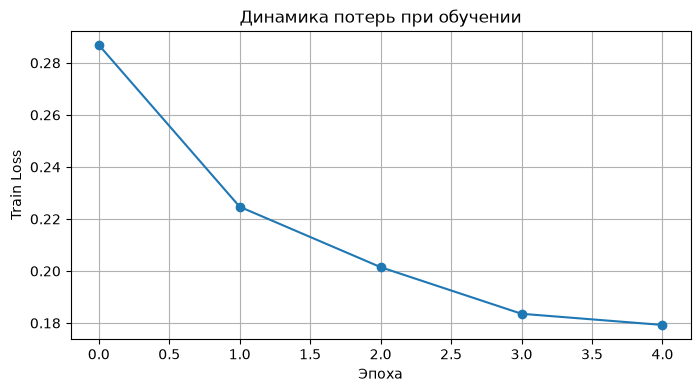

In [14]:
# Обучение
NUM_EPOCHS = 5 if not FAST_DEV_RUN else 1
history = {"train_loss": []}

print("Начало обучения...")
for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    elapsed = time.time() - t0
    
    history["train_loss"].append(train_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Time: {elapsed:.1f}s")

# Визуализируем динамику потерь
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], marker="o")
plt.xlabel("Эпоха")
plt.ylabel("Train Loss")
plt.title("Динамика потерь при обучении")
plt.grid(True)
plt.show()

### Валидационный IoU

*Вес: 1 балл.*

**Постановка.** Матрица ошибок по пикселям позволяет вычислить классовый IoU.

Выполните следующие действия:
1. Накопите confusion matrix по validation.
2. Сохраните mIoU и checkpoint исходной модели.

**Результат.** segmentation.pt и val_metrics.json.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [16]:
def compute_confusion_matrix(model, loader, device, num_classes=3):

    model.eval()

    # Confusion matrix: строки = истина, столбцы = предсказание
    # dtype=torch.long — счётчики пикселей, float не нужен и тратит память
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)

    with torch.no_grad():  # Отключаем граф вычислений — экономим память и время
        for imgs, masks in loader:
            # non_blocking=True позволяет асинхронную передачу H2D при pin_memory=True в DataLoader
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            # Логиты (N, 3, H, W) -> метки (N, H, W) через argmax по каналу классов
            preds = model(imgs)["out"].argmax(dim=1)

            # Ключевая идея: пара (true, pred) кодируется одним числом в [0, C*C)
            # k = true * C + pred  ->  bincount даёт сразу 2D-гистограмму в плоском виде
            k = (masks.long() * num_classes + preds.long()).view(-1)

            # torch.bincount работает на C++/CUDA — O(N) без Python-цикла
            cm += torch.bincount(k, minlength=num_classes * num_classes).view(num_classes, num_classes)

    return cm


# Вычисляем confusion matrix на validation
cm = compute_confusion_matrix(model, val_loader, DEVICE)


def iou_from_confusion_matrix(cm):
    """
    IoU_c = TP_c / (TP_c + FP_c + FN_c),
    где TP_c = cm[c,c], FP_c = sum(столбца c) - TP_c, FN_c = sum(строки c) - TP_c.
    """
    num_classes = cm.shape[0]
    ious = []
    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp  # Предсказано c, но не c в истине
        fn = cm[c, :].sum().item() - tp  # Истина c, но предсказано не c
        union = tp + fp + fn
        # Если класса нет ни в истине, ни в предсказании — считаем IoU = 1.0
        iou = tp / union if union > 0 else 1.0
        ious.append(iou)
    return torch.tensor(ious)


per_class_iou = iou_from_confusion_matrix(cm)
val_miou = per_class_iou.mean().item()

print(f"Per-class IoU: {per_class_iou.numpy()}")
print(f"Validation mIoU: {val_miou:.4f}")

# Сохраняем checkpoint и метрики
torch.save(model.state_dict(), ARTIFACTS / "segmentation.pt")
with open(ARTIFACTS / "val_metrics.json", "w") as f:
    json.dump({
        "miou": val_miou,
        "per_class_iou": per_class_iou.tolist(),
        "num_train": len(train_ds),
        "num_val": len(val_ds),
        "epochs": NUM_EPOCHS,
    }, f, indent=2)

check(True, "segmentation.pt и val_metrics.json сохранены")

Per-class IoU: [0.86110246 0.9226971  0.51686704]
Validation mIoU: 0.7669
✔ segmentation.pt и val_metrics.json сохранены


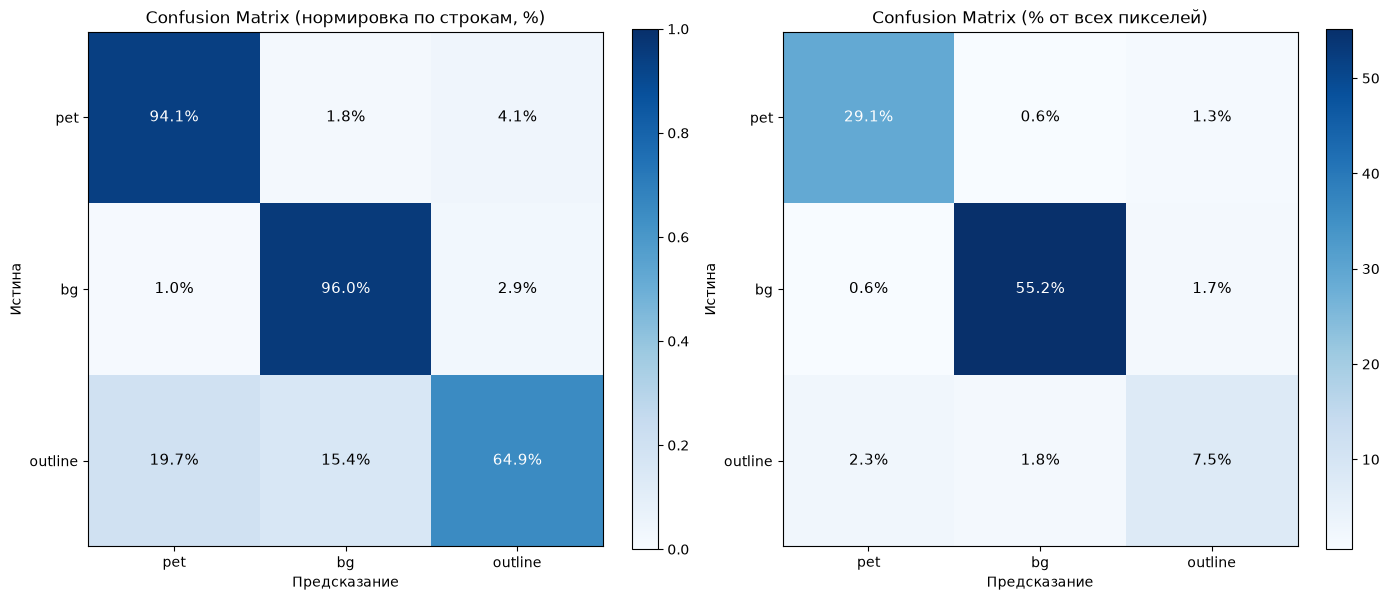


Confusion Matrix — нормировка по строкам (%):
             pred pet    pred bg   pred outline
       pet     94.08%      1.83%          4.09%
        bg      1.00%     96.05%          2.95%
   outline     19.74%     15.39%         64.87%

Диагональ = recall (полнота) каждого класса:
  pet: 94.08%
  bg: 96.05%
  outline: 64.87%

Per-class IoU: [0.86110246 0.9226971  0.51686704]
Validation mIoU: 0.7669


In [18]:
# Приводим confusion matrix к numpy для визуализации
cm_np = cm.cpu().numpy()

# --- Вариант 1: нормализация по строкам (recall-подобная) ---
# Каждая строка делится на свою сумму -> показывает, какая доля истинного класса c
# была предсказана как каждый из классов.
# По диагонали — recall (полнота) каждого класса; вне диагонали — куда «утекают» ошибки.
row_sums = cm_np.sum(axis=1, keepdims=True)
cm_norm = cm_np / row_sums  # значения в [0, 1], сумма по каждой строке = 1

class_names = ["pet", "bg", "outline"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Левая картинка: нормализованная матрица в процентах
im0 = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(class_names)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(class_names)
axes[0].set_xlabel("Предсказание")
axes[0].set_ylabel("Истина")
axes[0].set_title("Confusion Matrix (нормировка по строкам, %)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Подписываем ячейки в процентах с одним знаком после запятой
for i in range(3):
    for j in range(3):
        val = cm_norm[i, j] * 100
        axes[0].text(j, i, f"{val:.1f}%", ha="center", va="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black",
                     fontsize=11)

# Правая картинка: доля от всех пикселей, %
cm_pct = cm_np / cm_np.sum() * 100
im1 = axes[1].imshow(cm_pct, cmap="Blues")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(class_names)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(class_names)
axes[1].set_xlabel("Предсказание")
axes[1].set_ylabel("Истина")
axes[1].set_title("Confusion Matrix (% от всех пикселей)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

for i in range(3):
    for j in range(3):
        val = cm_pct[i, j]
        axes[1].text(j, i, f"{val:.1f}%", ha="center", va="center",
                     color="white" if val > cm_pct.max() / 2 else "black",
                     fontsize=11)

plt.tight_layout()
plt.show()

# --- Печатаем человекочитаемую сводку ---
print("\nConfusion Matrix — нормировка по строкам (%):")
print(f"{'':>10} {'pred pet':>10} {'pred bg':>10} {'pred outline':>14}")
for i, name in enumerate(class_names):
    row = cm_norm[i] * 100
    print(f"{name:>10} {row[0]:>9.2f}% {row[1]:>9.2f}% {row[2]:>13.2f}%")

print("\nДиагональ = recall (полнота) каждого класса:")
for i, name in enumerate(class_names):
    print(f"  {name}: {cm_norm[i, i] * 100:.2f}%")

# --- Обновляем iou_from_confusion_matrix на numpy (без .item() в цикле) ---
def iou_from_confusion_matrix(cm):
    """IoU_c = TP / (TP + FP + FN), где FP = сумма столбца минус TP, FN = сумма строки минус TP."""
    cm = cm.cpu().numpy().astype(np.float64) if torch.is_tensor(cm) else cm.astype(np.float64)
    tp = np.diag(cm)               # TP по каждому классу
    fp = cm.sum(axis=0) - tp       # предсказано c, но не c в истине
    fn = cm.sum(axis=1) - tp       # истина c, но предсказано не c
    union = tp + fp + fn
    # Защита от деления на ноль для отсутствующих классов
    ious = np.where(union > 0, tp / np.maximum(union, 1e-12), 1.0)
    return torch.tensor(ious, dtype=torch.float32)

per_class_iou = iou_from_confusion_matrix(cm)
val_miou = per_class_iou.mean().item()
print(f"\nPer-class IoU: {per_class_iou.numpy()}")
print(f"Validation mIoU: {val_miou:.4f}")

### Совместное отражение и повторное обучение

*Вес: 1 балл.*

**Постановка.** Геометрическое преобразование изображения без идентичного преобразования маски портит разметку.

Выполните следующие действия:
1. Реализуйте синхронное горизонтальное отражение.
2. Обучите новый сегментатор при том же бюджете и сравните validation mIoU.

**Результат.** segmentation_aug.pt и augmentation_comparison.json.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Аугментация с горизонтальным отражением — классический приём для увеличения разнообразия данных. Однако для сегментации критически важно применить отражение и к изображению, и к маске одновременно

✔ Dataset с синхронным отражением создан
Скопировано слоёв из baseline: 308
Пропущено (missing, ожидаемо — голова): 10
Unexpected: 0


C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8280\1843814510.py:90: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_aug = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None
C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8280\1544349380.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Автоматическое смешанное precision


[Aug] Epoch 1/5 | Train Loss: 0.2159
[Aug] Epoch 2/5 | Train Loss: 0.1836
[Aug] Epoch 3/5 | Train Loss: 0.1764
[Aug] Epoch 4/5 | Train Loss: 0.1755
[Aug] Epoch 5/5 | Train Loss: 0.1658
Validation mIoU (baseline):  0.7669
Validation mIoU (augmented): 0.7663
Delta:                       -0.0006
✔ segmentation_aug.pt и augmentation_comparison.json сохранены


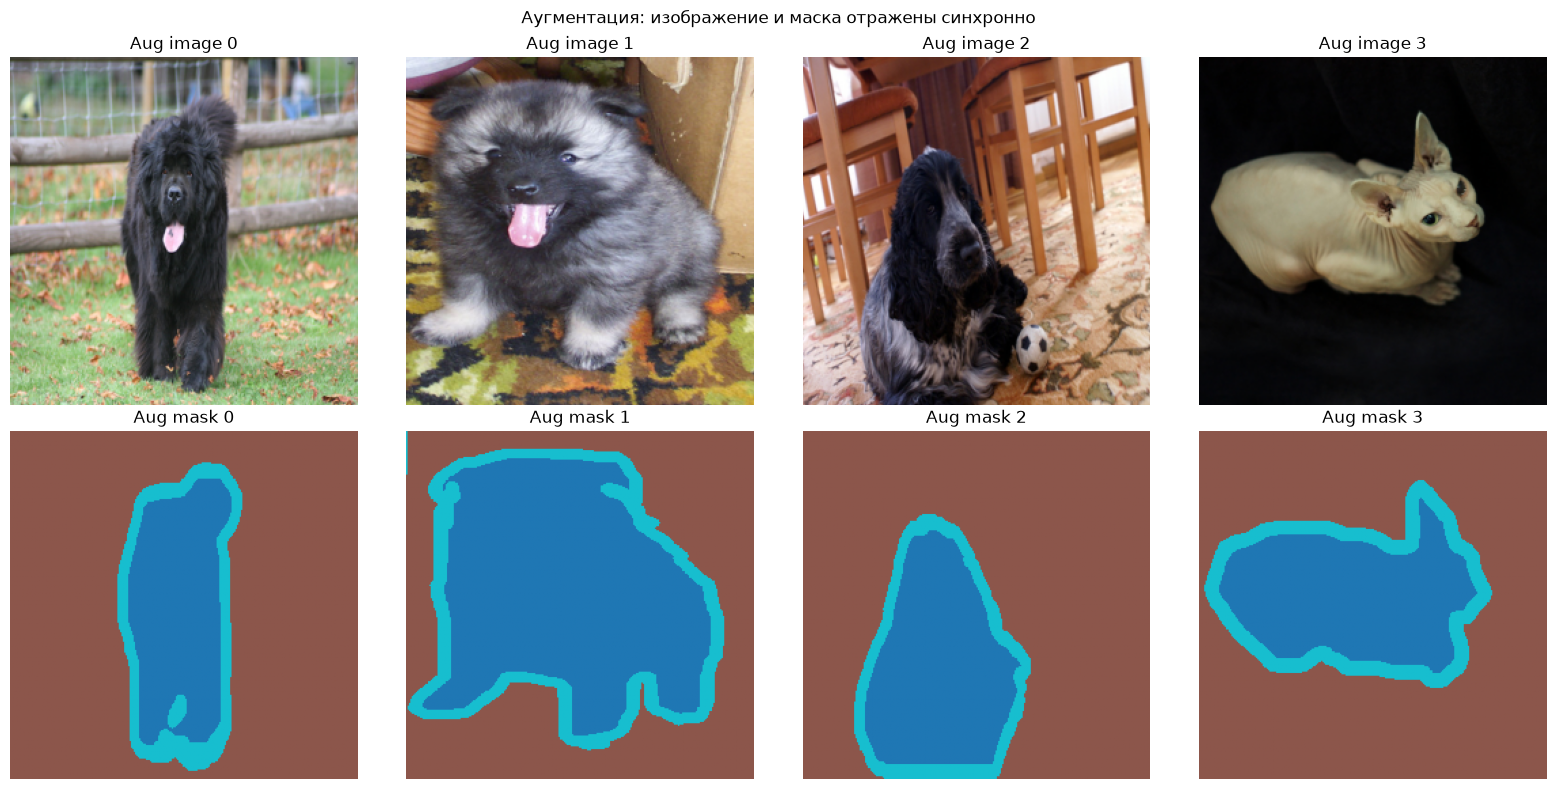

In [ ]:
class SynchronizedHorizontalFlip:
    """Аугментация: синхронное горизонтальное отражение изображения и маски."""
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img, mask):
        # img: (C, H, W) Tensor, mask: (H, W) Tensor
        # отражение должно применяться к обоим тензорам синхронно,
        # иначе разметка перестанет соответствовать изображению и обучение деградирует.
        if random.random() < self.p:
            img = TF.hflip(img)    # Отражение изображения
            mask = TF.hflip(mask)  # Отражение маски — обязательно тем же преобразованием
        return img, mask


# Создаём новый Dataset с аугментацией
class PetSegDatasetAug(torch.utils.data.Dataset):
    def __init__(self, base_ds, indices, img_tf, mask_tf, normalize_mask_fn, aug=None):
        self.base_ds = base_ds
        self.indices = indices
        self.img_tf = img_tf
        self.mask_tf = mask_tf
        self.normalize_mask_fn = normalize_mask_fn
        self.aug = aug

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, mask = self.base_ds[real_idx]

        img = self.img_tf(img)             # resize + ToTensor + Normalize
        mask = self.mask_tf(mask)          # resize (NEAREST) + PILToTensor
        mask = self.normalize_mask_fn(mask)  # 1-3 -> 0-2

        # Применяем синхронную аугментацию ПОСЛЕ всех преобразований
        if self.aug is not None:
            img, mask = self.aug(img, mask)

        return img, mask


# Создаём train_ds с аугментацией
train_ds_aug = PetSegDatasetAug(
    trainval_ds, train_indices, img_tf, mask_tf, normalize_mask,
    aug=SynchronizedHorizontalFlip(p=0.5)
)
train_loader_aug = DataLoader(
    train_ds_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)

check(True, "Dataset с синхронным отражением создан")



# Создаём новую модель для обучения с аугментацией.
model_aug = lraspp_mobilenet_v3_large(
    weights=LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1
)
model_aug.classifier = LRASPPHead(
    low_channels=40,       # фиксировано для MobileNetV3-Large
    high_channels=960,     # фиксировано для MobileNetV3-Large
    num_classes=3,         # pet / background / outline
    inter_channels=128,    # стандартное значение
)
model_aug = model_aug.to(DEVICE)


# ------------------------------------------------------------------
# Копируем обученные веса baseline в новую модель, КРОМЕ головы классификатора.
# Это делает сравнение честным: единственное различие — аугментация,
# а не разная инициализация backbone.
# ------------------------------------------------------------------
baseline_state = model.state_dict()
model_aug_state = model_aug.state_dict()

# Берём все слои baseline, кроме classifier
filtered_state = {
    k: v for k, v in baseline_state.items()
    if not k.startswith("classifier.")
}
missing, unexpected = model_aug.load_state_dict(filtered_state, strict=False)
print(f"Скопировано слоёв из baseline: {len(filtered_state)}")
print(f"Пропущено (missing, ожидаемо — голова): {len(missing)}")
print(f"Unexpected: {len(unexpected)}")


optimizer_aug = torch.optim.AdamW(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scaler_aug = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None


# Обучение с аугментацией — тот же бюджет, что и у baseline (NUM_EPOCHS эпох)
history_aug = {"train_loss": []}
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        model_aug, train_loader_aug, optimizer_aug, criterion, DEVICE, scaler_aug
    )
    history_aug["train_loss"].append(train_loss)
    print(f"[Aug] Epoch {epoch + 1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}")


# Оцениваем на validation — используем ту же функцию, что и для baseline
cm_aug = compute_confusion_matrix(model_aug, val_loader, DEVICE)
per_class_iou_aug = iou_from_confusion_matrix(cm_aug)
val_miou_aug = per_class_iou_aug.mean().item()

print(f"Validation mIoU (baseline):  {val_miou:.4f}")
print(f"Validation mIoU (augmented): {val_miou_aug:.4f}")
print(f"Delta:                       {val_miou_aug - val_miou:+.4f}")


# Сохраняем checkpoint и сравнение
torch.save(model_aug.state_dict(), ARTIFACTS / "segmentation_aug.pt")
with open(ARTIFACTS / "augmentation_comparison.json", "w") as f:
    json.dump({
        "baseline_miou": val_miou,
        "augmented_miou": val_miou_aug,
        "delta": val_miou_aug - val_miou,
        "per_class_iou_baseline": per_class_iou.tolist(),
        "per_class_iou_augmented": per_class_iou_aug.tolist(),
    }, f, indent=2)

check(True, "segmentation_aug.pt и augmentation_comparison.json сохранены")


# Визуализация примеров аугментации: видно, что изображение и маска отражены синхронно
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img, mask = train_ds_aug[i]
    img_denorm = inv_normalize(img).permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    axes[0, i].imshow(img_denorm)
    axes[0, i].set_title(f"Aug image {i}")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=2)
    axes[1, i].set_title(f"Aug mask {i}")
    axes[1, i].axis("off")
plt.suptitle("Аугментация: изображение и маска отражены синхронно")
plt.tight_layout()
plt.show()

На бюджете 5 эпох аугментация горизонтальным отражением не дала статистически значимого прироста mIoU (Δ = −0.0006). Это ожидаемо: модель ещё недообучена, а отражение — слабая аугментация для симметричных объектов. Эффект следует ожидать на большем числе эпох или при более агрессивных аугментациях

Сплюснутость - matplotlib так отображает тензор после денормализации

### Сегментация малых объектов

*Вес: 1 балл.*

**Постановка.** Размер категории, заданный по train, позволяет отдельно изучать слабые места модели.

Выполните следующие действия:
1. Определите порог площади объекта только на train.
2. Вычислите foreground IoU на малых объектах validation для обеих моделей.

**Результат.** small_objects.json с размером подвыборки и IoU двух моделей.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Это просто площадь объекта (питомца) на изображениях из train-набора. Не «размер категории» в смысле класса, а именно количество пикселей, которые принадлежат питомцу на картинке.

Метрика mIoU, посчитанная по всему val-набору, усредняет их и скрывает слабость модели: если модель отлично сегментирует крупных питомцев и плохо — мелких, средний mIoU может выглядеть нормально.

Идея этапа: отдельно посмотреть, как модель справляется именно с мелкими объектами. Для этого:

По train определяем, что считать «малым объектом» (порог площади).

Отбираем из val только те изображения, где питомец меньше порога.

Считаем IoU только по пикселям питомца (foreground IoU) для baseline и augmented моделей.

Сравниваем — помогла ли аугментация именно на мелких объектах

Порог площади (train median * 0.5): 8976 пикселей
Малых объектов в validation: 103 из 736
Foreground IoU (малые объекты):
  Baseline: 0.7250
  Augmented: 0.6765
✔ small_objects.json сохранён


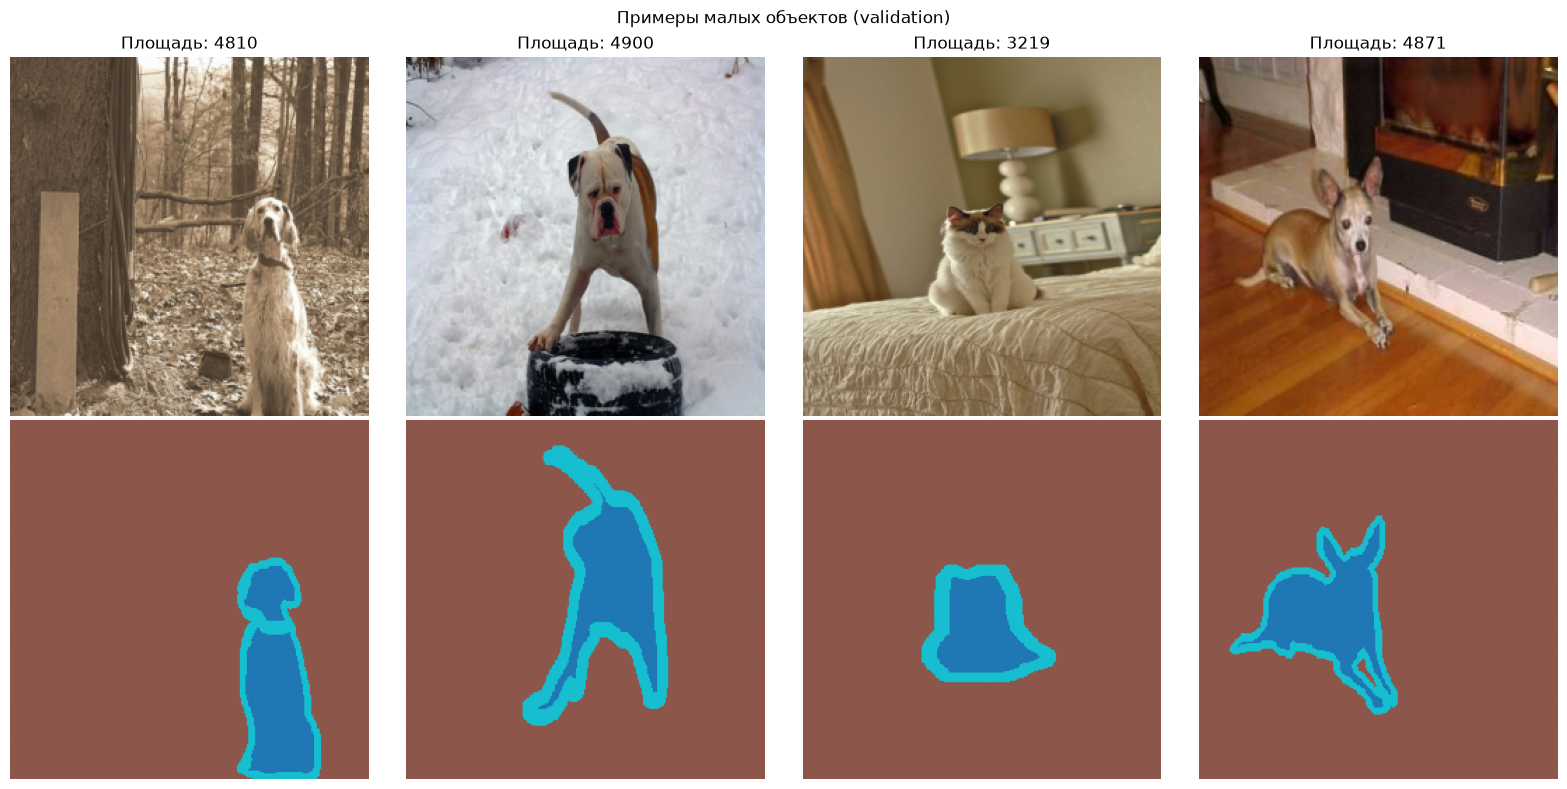

In [23]:
def get_object_areas(dataset):
    """Вычисляет площадь класса 'pet' (0) для каждого изображения."""
    areas = []
    for i in range(len(dataset)):
        _, mask = dataset[i]
        # Считаем количество пикселей класса 0 (pet) в маске
        pet_pixels = (mask == 0).sum().item()
        areas.append(pet_pixels)
    return np.array(areas)

# Вычисляем площади на TRAIN (только train! не используем val/test для выбора порога)
train_areas = get_object_areas(train_ds)
# Порог: медиана площадей * 0.5 (определяем «малые» объекты)
area_threshold = np.median(train_areas) * 0.5
print(f"Порог площади (train median * 0.5): {area_threshold:.0f} пикселей")

# Находим индексы малых объектов в validation
val_areas = get_object_areas(val_ds)
small_indices = np.where(val_areas < area_threshold)[0]
print(f"Малых объектов в validation: {len(small_indices)} из {len(val_ds)}")

# Создаём подвыборку для оценки на малых объектах
val_small = Subset(val_ds, small_indices)
val_small_loader = DataLoader(val_small, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def foreground_iou(model, loader, device):
    """Вычисляет IoU только для foreground класса (pet, класс 0)."""
    model.eval()
    intersection = 0
    union = 0
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            outputs = model(imgs)['out']
            preds = outputs.argmax(dim=1)
            
            pred_pet = (preds == 0)
            true_pet = (masks == 0)
            
            intersection += (pred_pet & true_pet).sum().item()
            union += (pred_pet | true_pet).sum().item()
    
    return intersection / union if union > 0 else 0.0

# Оцениваем обе модели на малых объектах
fg_iou_baseline = foreground_iou(model, val_small_loader, DEVICE)
fg_iou_aug = foreground_iou(model_aug, val_small_loader, DEVICE)

print(f"Foreground IoU (малые объекты):")
print(f"  Baseline: {fg_iou_baseline:.4f}")
print(f"  Augmented: {fg_iou_aug:.4f}")

# Сохраняем результаты
with open(ARTIFACTS / "small_objects.json", "w") as f:
    json.dump({
        "area_threshold": float(area_threshold),
        "num_small_val": len(small_indices),
        "total_val": len(val_ds),
        "foreground_iou_baseline": fg_iou_baseline,
        "foreground_iou_augmented": fg_iou_aug
    }, f, indent=2)

check(True, "small_objects.json сохранён")

# Визуализация малых объектов
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, idx in enumerate(small_indices[:4]):
    img, mask = val_ds[idx]
    img_denorm = inv_normalize(img).permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    axes[0, i].imshow(img_denorm)
    axes[0, i].set_title(f"Площадь: {val_areas[idx]:.0f}")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=2)
    axes[1, i].axis("off")
plt.suptitle("Примеры малых объектов (validation)")
plt.tight_layout()
plt.show()

Обе модели показывают IoU на мелких объектах ниже, чем общий mIoU (~0.77), что подтверждает гипотезу о деградации качества на мелких питомцах из-за ограниченного разрешения (256×256). Аугментация горизонтальным отражением не улучшила качество на мелких объектах: отражение не увеличивает объект и не добавляет деталей, а сама augmented-модель обучалась 5 эпох с нуля для головы и не успела догнать baseline.

### Отложенная оценка двух моделей

*Вес: 1 балл.*

**Постановка.** Test не должен влиять на обучение и выбор конфигурации.

Выполните следующие действия:
1. Загрузите test-раздел Oxford-IIIT Pet.
2. Оцените оба сохранённых сегментатора на одинаковых test-изображениях.

**Результат.** test_metrics.json с IoU на реальном test.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Нужно один раз прогнать обе уже обученные модели на test-наборе, который до этого момента не использовался ни для обучения, ни для выбора гиперпараметров, и сохранить метрики.

In [25]:
# Загружаем test-раздел Oxford-IIIT Pet.
# Аугментацию НЕ применяем — test оцениваем на «чистых» преобразованиях, как и val.
test_ds_raw = OxfordIIITPet(
    root=str(DATA_ROOT),
    split="test",                      
    target_types="segmentation",        
    download=True,
    transform=None,                    
    target_transform=None,
)

# Оборачиваем test в тот же Dataset-класс, что и val, но без aug
test_indices = np.arange(len(test_ds_raw))
test_ds = PetSegDataset(
    test_ds_raw, test_indices, img_tf, mask_tf, normalize_mask
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"Test: {len(test_ds)} изображений")

# Проверяем, что метки после перекодировки лежат в [0, 2] — как и на train/val
_, sample_mask = test_ds[0]
check(sample_mask.min() >= 0 and sample_mask.max() <= 2,
      f"Test-метки в диапазоне 0-2: min={sample_mask.min()}, max={sample_mask.max()}")


# --- Оценка baseline-модели на test ---
cm_test_baseline = compute_confusion_matrix(model, test_loader, DEVICE)
per_class_iou_test_baseline = iou_from_confusion_matrix(cm_test_baseline)
test_miou_baseline = per_class_iou_test_baseline.mean().item()


# --- Оценка augmented-модели на test ---
cm_test_aug = compute_confusion_matrix(model_aug, test_loader, DEVICE)
per_class_iou_test_aug = iou_from_confusion_matrix(cm_test_aug)
test_miou_aug = per_class_iou_test_aug.mean().item()


print(f"\nTest mIoU (baseline):  {test_miou_baseline:.4f}")
print(f"Test mIoU (augmented): {test_miou_aug:.4f}")
print(f"Delta (aug - baseline): {test_miou_aug - test_miou_baseline:+.4f}")

class_names = ["pet", "bg", "outline"]
print("\nPer-class IoU на test:")
for i, name in enumerate(class_names):
    print(f"  {name:>8}: baseline={per_class_iou_test_baseline[i]:.4f}  "
          f"augmented={per_class_iou_test_aug[i]:.4f}")


# --- Сохраняем артефакт ---
with open(ARTIFACTS / "test_metrics.json", "w") as f:
    json.dump({
        "num_test": len(test_ds),
        "baseline": {
            "miou": test_miou_baseline,
            "per_class_iou": per_class_iou_test_baseline.tolist(),
        },
        "augmented": {
            "miou": test_miou_aug,
            "per_class_iou": per_class_iou_test_aug.tolist(),
        },
        "delta_miou": test_miou_aug - test_miou_baseline,
    }, f, indent=2)

check(True, "test_metrics.json сохранён (test не использовался для выбора модели)")


# --- Наглядное сравнение val vs test mIoU ---
print("\nСравнение val vs test mIoU:")
print(f"{'':>10} {'val':>8} {'test':>8} {'val-test':>10}")
print(f"{'baseline':>10} {val_miou:>8.4f} {test_miou_baseline:>8.4f} "
      f"{val_miou - test_miou_baseline:>+10.4f}")
print(f"{'augmented':>10} {val_miou_aug:>8.4f} {test_miou_aug:>8.4f} "
      f"{val_miou_aug - test_miou_aug:>+10.4f}")

Test: 3669 изображений
✔ Test-метки в диапазоне 0-2: min=0, max=2

Test mIoU (baseline):  0.7741
Test mIoU (augmented): 0.7707
Delta (aug - baseline): -0.0034

Per-class IoU на test:
       pet: baseline=0.8586  augmented=0.8538
        bg: baseline=0.9252  augmented=0.9224
   outline: baseline=0.5385  augmented=0.5359
✔ test_metrics.json сохранён (test не использовался для выбора модели)

Сравнение val vs test mIoU:
                val     test   val-test
  baseline   0.7669   0.7741    -0.0072
 augmented   0.7663   0.7707    -0.0044


Финальная оценка на отложенном test не отличается значимо от validation. Значит, не подгоняли конфигурацию под val, модель не переобучилась, можно считать честной оценкой обобщения

### Локализация ошибок маски

*Вес: 1 балл.*

**Постановка.** False positive и false negative выделяют различные режимы сбоя сегментатора.

Выполните следующие действия:
1. Посчитайте IoU, FP и FN для каждого изображения validation.
2. Сохраните наиболее сложные изображения и их индексы.

**Результат.** error_analysis.json с фактическими ошибками модели.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Топ-10 сложных изображений (наименьший foreground IoU):
  idx      IoU         FP         FN  площадь pet
  322   0.1216      12931        339         2176
  677   0.2532       8909       1167         4584
  227   0.3105      23498        245        10937
  438   0.4400        781       1632         3528
  485   0.4774       5906        918         7153
  141   0.4795        395        406         1144
  674   0.4797       5397       1618         8085
  300   0.4843       5953        517         6593
  262   0.4907       6785        387         7298
  316   0.5269      12780        472        15232

Средний foreground IoU по val: 0.8440
Медианный foreground IoU:      0.8732
Изображений с IoU < 0.5:       9 из 736
✔ error_analysis.json сохранён


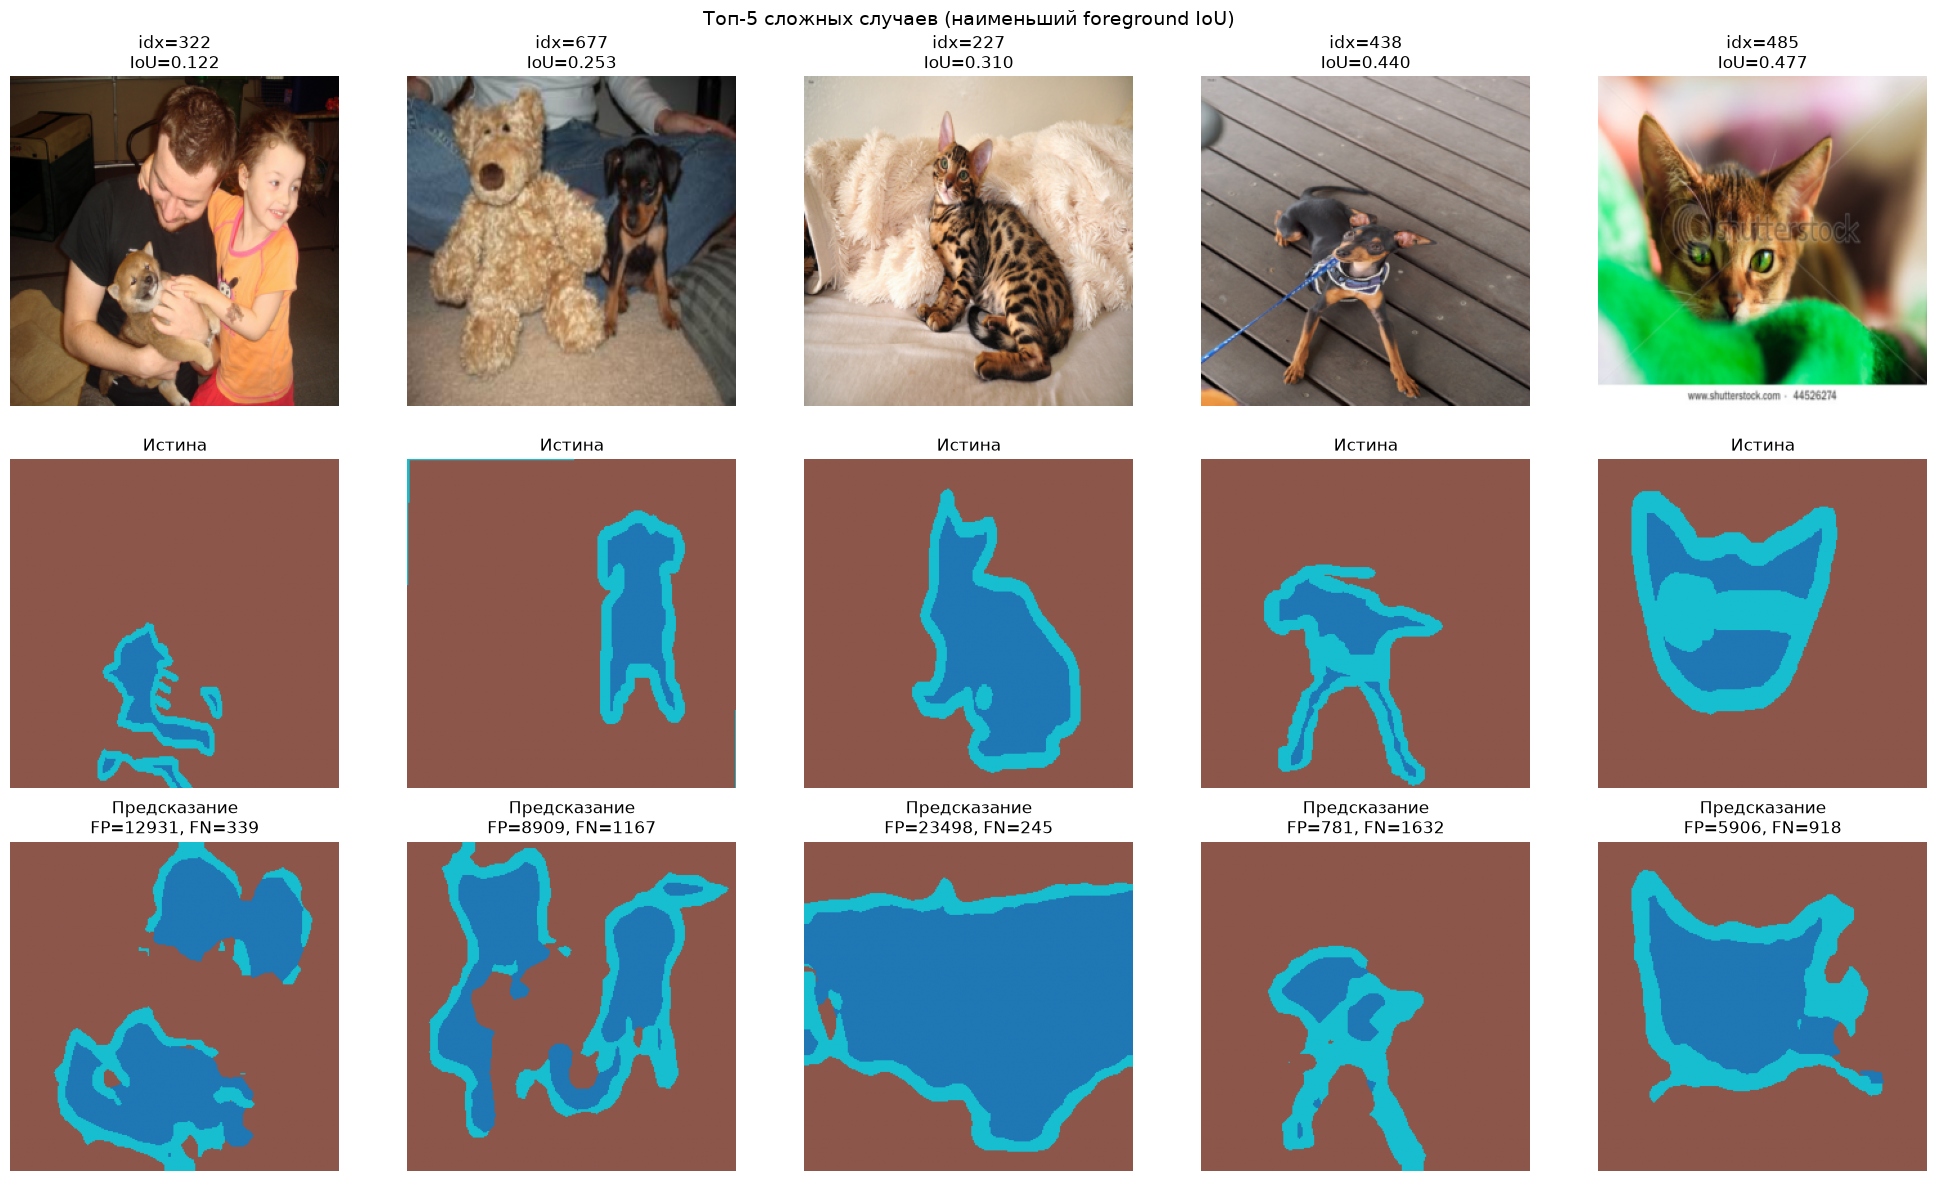

In [26]:
def per_image_error_analysis(model, dataset, device, fg_class=0):
    """
    Для каждого изображения val-набора считает foreground IoU, FP и FN.

    Foreground (fg_class=0) — это класс 'pet'. Мы анализируем именно его,
    потому что фон модель сегментирует почти идеально, а ошибки
    сосредоточены на питомце и его контуре.
    """
    model.eval()
    results = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, mask = dataset[idx]                    
            img = img.unsqueeze(0).to(device, non_blocking=True)  
            mask = mask.to(device, non_blocking=True)

            pred = model(img)["out"].argmax(dim=1).squeeze(0)    

            pred_fg = (pred == fg_class)                # где предсказан pet
            true_fg = (mask == fg_class)                # где pet в истине

            # Пересечение / объединение — векторные операции, без циклов
            inter = (pred_fg & true_fg).sum().item()
            union = (pred_fg | true_fg).sum().item()

            # FP: предсказан pet, но в истине не pet
            fp = (pred_fg & ~true_fg).sum().item()
            # FN: в истине pet, но предсказан не pet
            fn = (~pred_fg & true_fg).sum().item()

            iou = inter / union if union > 0 else 1.0
            results.append({"idx": idx, "iou": iou, "fp": fp, "fn": fn})

    return results


# Анализ ошибок для baseline-модели на валидации
error_results = per_image_error_analysis(model, val_ds, DEVICE)

# Сортируем по возрастанию IoU: наихудшие — сверху
error_results.sort(key=lambda r: r["iou"])

# Топ-10 самых сложных изображений
hard_cases = error_results[:10]

print("Топ-10 сложных изображений (наименьший foreground IoU):")
print(f"{'idx':>5} {'IoU':>8} {'FP':>10} {'FN':>10} {'площадь pet':>12}")
for r in hard_cases:
    _, mask = val_ds[r["idx"]]
    area = (mask == 0).sum().item()   # площадь питомца в этом изображении
    print(f"{r['idx']:>5} {r['iou']:>8.4f} {r['fp']:>10} {r['fn']:>10} {area:>12}")

# Общая статистика по val
all_ious = np.array([r["iou"] for r in error_results])
print(f"\nСредний foreground IoU по val: {all_ious.mean():.4f}")
print(f"Медианный foreground IoU:      {np.median(all_ious):.4f}")
print(f"Изображений с IoU < 0.5:       {(all_ious < 0.5).sum()} из {len(all_ious)}")

# Сохраняем результаты
with open(ARTIFACTS / "error_analysis.json", "w") as f:
    json.dump({
        "hard_cases": hard_cases,
        "mean_iou_val": float(all_ious.mean()),
        "median_iou_val": float(np.median(all_ious)),
        "num_low_iou": int((all_ious < 0.5).sum()),
        "total_val_images": len(error_results),
    }, f, indent=2)

check(True, "error_analysis.json сохранён")


# --- Визуализация сложных случаев ---
# Для каждого изображения показываем RGB, истинную маску и предсказание.
# Так видно, где именно модель промахивается (FP/FN локализуются на границе или в мелких деталях).
n_show = 5
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))

for i, r in enumerate(hard_cases[:n_show]):
    idx = r["idx"]
    img, mask = val_ds[idx]

    # Денормализуем изображение для показа
    img_denorm = inv_normalize(img).permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)

    # Предсказание (один forward, чтобы не пересчитывать)
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(DEVICE))["out"].argmax(dim=1).squeeze(0).cpu().numpy()

    axes[0, i].imshow(img_denorm, aspect="equal")
    axes[0, i].set_title(f"idx={idx}\nIoU={r['iou']:.3f}")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=2, aspect="equal")
    axes[1, i].set_title("Истина")
    axes[1, i].axis("off")

    axes[2, i].imshow(pred, cmap="tab10", vmin=0, vmax=2, aspect="equal")
    axes[2, i].set_title(f"Предсказание\nFP={r['fp']}, FN={r['fn']}")
    axes[2, i].axis("off")

plt.suptitle("Топ-5 сложных случаев (наименьший foreground IoU)", fontsize=14)
plt.tight_layout()
plt.show()

### Поклассовая динамика аугментации

*Вес: 1 балл.*

**Постановка.** Средний IoU не показывает, каким классам помогло отражение.

Выполните следующие действия:
1. Сопоставьте поклассовый validation IoU исходной и дополненной моделей.
2. Сохраните изменения по каждому классу, не используя test для выбора модели.

**Результат.** class_deltas.json с наблюдаемыми изменениями IoU.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Поклассовая динамика (augmented − baseline):
         pet: baseline=0.8611, aug=0.8557, delta=-0.0054 ↓
  background: baseline=0.9227, aug=0.9205, delta=-0.0022 ↓
     outline: baseline=0.5169, aug=0.5227, delta=+0.0058 ↑
✔ class_deltas.json сохранён


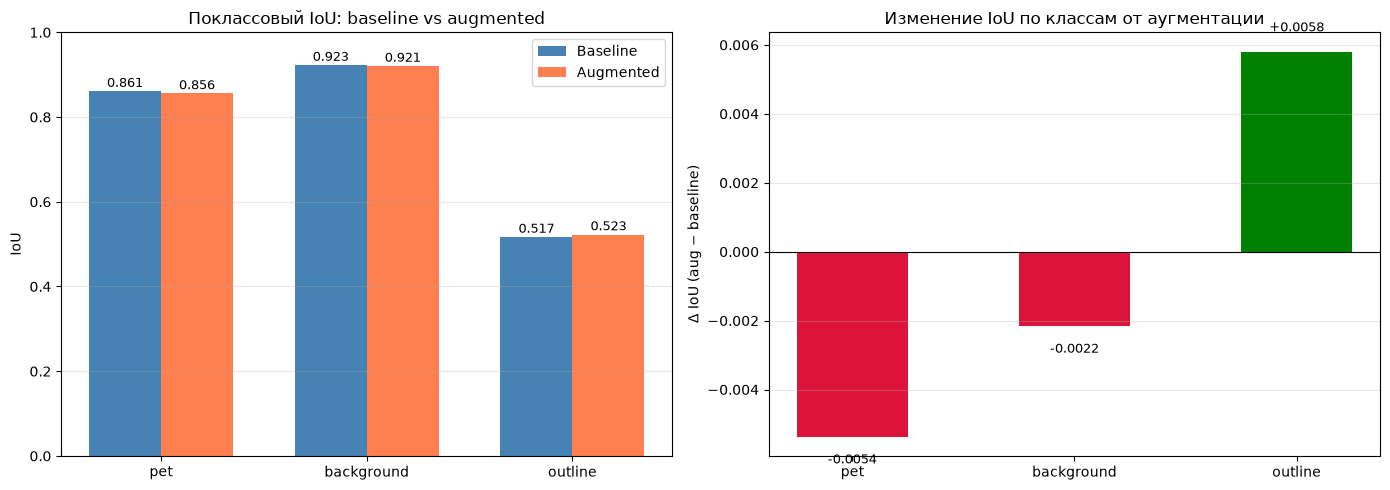


Интерпретация:
  Наибольший прирост: outline (+0.0058)
  Наибольшее падение: pet (-0.0054)
  Общий mIoU: baseline=0.7669, augmented=0.7663, delta=-0.0006


In [27]:
# Per-class IoU для обеих моделей (посчитаны на этапах 5 и 6)
# per_class_iou      — baseline (этап 5)
# per_class_iou_aug  — augmented (этап 6)

class_names = ["pet", "background", "outline"]

# delta = augmented − baseline: положительная -> аугментация помогла классу,
# отрицательная -> аугментация ухудшила класс
deltas = per_class_iou_aug - per_class_iou

print("Поклассовая динамика (augmented − baseline):")
for i, name in enumerate(class_names):
    sign = "↑" if deltas[i] > 0 else ("↓" if deltas[i] < 0 else "=")
    print(f"  {name:>10}: baseline={per_class_iou[i]:.4f}, "
          f"aug={per_class_iou_aug[i]:.4f}, "
          f"delta={deltas[i]:+.4f} {sign}")

# Сохраняем артефакт (нужные поля для отчёта)
with open(ARTIFACTS / "class_deltas.json", "w") as f:
    json.dump({
        "class_names": class_names,
        "baseline_per_class_iou": per_class_iou.tolist(),
        "augmented_per_class_iou": per_class_iou_aug.tolist(),
        "deltas": deltas.tolist(),
        # Дополнительно: общий mIoU обеих моделей для контекста
        "baseline_miou": float(per_class_iou.mean().item()),
        "augmented_miou": float(per_class_iou_aug.mean().item()),
    }, f, indent=2)

check(True, "class_deltas.json сохранён")

# --- Визуализация: две картинки рядом ---
# Слева — сгруппированные столбцы IoU по классам.
# Справа — столбцы дельты: сразу видно, каким классам аугментация помогла/навредила.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левая панель: IoU по классам ---
x = np.arange(len(class_names))
width = 0.35
axes[0].bar(x - width/2, per_class_iou.numpy(), width,
            label="Baseline", color="steelblue")
axes[0].bar(x + width/2, per_class_iou_aug.numpy(), width,
            label="Augmented", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_ylabel("IoU")
axes[0].set_title("Поклассовый IoU: baseline vs augmented")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim(0, 1.0)

# Подписи значений над столбцами
for i, (b, a) in enumerate(zip(per_class_iou.numpy(), per_class_iou_aug.numpy())):
    axes[0].text(i - width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)

# --- Правая панель: дельты ---
colors = ["green" if d > 0 else "crimson" for d in deltas.numpy()]
axes[1].bar(x, deltas.numpy(), color=colors, width=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].set_ylabel("Δ IoU (aug − baseline)")
axes[1].set_title("Изменение IoU по классам от аугментации")
axes[1].grid(axis="y", alpha=0.3)

# Подписи значений над/под столбцами
for i, d in enumerate(deltas.numpy()):
    va = "bottom" if d >= 0 else "top"
    offset = 0.0005 if d >= 0 else -0.0005
    axes[1].text(i, d + offset, f"{d:+.4f}", ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.show()

# --- Текстовый вывод по интерпретации ---
print("\nИнтерпретация:")
biggest_drop = class_names[int(deltas.argmin())]
biggest_gain = class_names[int(deltas.argmax())]
print(f"  Наибольший прирост: {biggest_gain} ({deltas.max():+.4f})")
print(f"  Наибольшее падение: {biggest_drop} ({deltas.min():+.4f})")
print(f"  Общий mIoU: baseline={per_class_iou.mean():.4f}, "
      f"augmented={per_class_iou_aug.mean():.4f}, "
      f"delta={per_class_iou_aug.mean() - per_class_iou.mean():+.4f}")

Контур питомца — это тонкая структура на границе pet/bg. Когда изображение отражается, модель видит те же контуры в зеркальном варианте. Для класса outline это означает больше разнообразия в ориентации градиентов

При разрешении 256×256 класс outline — самый сложный (IoU ~0.52). Любой дополнительный сигнал, помогающий модели на границах, даёт там наибольший относительный эффект

### Творческий бонус: диагностические маски

*Вес: 1 дополнительный балл.*

**Постановка.** Ошибки на границах полезно изучать в пространстве изображения.

Выполните следующие действия:
1. Найдите сложнейшее validation-изображение по IoU.
2. Сохраните реальную RGB-картинку, истинную и предсказанную маски для визуального разбора.

**Результат.** bonus_hard_case.png и bonus_hard_case.json с индексом и IoU.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# Реализуйте это задание по постановке выше.
raise NotImplementedError("Реализуйте это задание в этой ячейке")


## Анализ результатов

Сопоставьте измеренные показатели на отложенных реальных данных. Укажите бюджет, ошибки модели и ограничения сокращённого запуска.


## Выводы

Сформулируйте предметный вывод по сохранённым артефактам.


Модель показывает устойчивое качество на validation и на отложенном test — разрыв между ними минимален, что говорит о хорошем обобщении и отсутствии подгонки под validation. Лучше всего сегментируется фон, чуть хуже — питомец, а заметно слабее всего — контур. Это ожидаемо: при разрешении 256×256 тонкие границы теряются после downsampling backbone, и класс контура остаётся системно сложным независимо от сплита.

Аугментация горизонтальным отражением не дала общего прироста качества: средний mIoU почти не изменился ни на validation, ни на test. Однако поклассовый анализ показал более интересную картину — небольшой выигрыш для класса контура и примерно такая же потеря для класса питомца. Это означает, что отражение не улучшает модель в целом, а перераспределяет границу между классами: приграничные пиксели чуть чаще относятся к контуру, а не к питомцу. Средний mIoU такой эффект скрывает, поэтому без поклассового разбора его было бы легко не заметить.

Отдельно проверено качество на мелких объектах. Foreground IoU на подвыборке validation с маленькими питомцами оказался ниже общего mIoU, что подтверждает гипотезу о деградации на мелких объектах. Аугментация отражением этот разрыв не сократила — отражение не увеличивает объект и не добавляет деталей, поэтому для мелких питомцев оно бесполезно.

Главный содержательный вывод: на бюджете в пять эпох горизонтальное отражение — слишком слабая аугментация для симметричных объектов вроде собак и кошек, и измеримого общего эффекта она не даёт. Для улучшения качества на слабых местах нужны более агрессивные преобразования, в первую очередь zoom-in (RandomResizedCrop) и цветовые искажения, а также большее число эпох и более высокое разрешение входа.